# Лабораторная работа №5. Подбор гиперпараметров.

In [7]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from scipy.stats import randint, loguniform, uniform
# Импортируем классы для байесовского поиска из scikit-optimize
from skopt import BayesSearchCV
from skopt.space import Integer, Real, Categorical

import warnings
warnings.filterwarnings("ignore")

# Список для хранения результатов всех экспериментов
results = []

# Загрузка данных и настройка общих параметров поиска

In [2]:
df = pd.read_csv('df_processed.csv')
X = df.drop(columns=['price'])
y = df['price']

# Разбиение на train и test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

# Базовые модели с заданными параметрами random_state и n_jobs
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
xgb_base = XGBRegressor(random_state=42, n_jobs=-1)

# Вспомогательная функция для оценки модели и сохранения результатов
def evaluate_and_save(model_name, method_name, search_object, start_time):
    execution_time = time.time() - start_time
    best_model = search_object.best_estimator_
    y_pred = best_model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"--- {model_name} | {method_name} ---")
    print(f"Лучшие параметры: {search_object.best_params_}")
    print(f"R2 на кросс-валидации (train): {search_object.best_score_:.4f}")
    print(f"Метрики на тесте -> MSE: {mse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")
    print(f"Время выполнения: {execution_time:.2f} сек.\n")
    
    results.append({
        'Model': model_name,
        'Method': method_name,
        'MSE': mse,
        'MAE': mae,
        'R2': r2,
        'Time (s)': execution_time
    })

Размер обучающей выборки: (8160, 17)
Размер тестовой выборки: (2040, 17)


# Метод 1: Поиск по решетке (GridSearchCV)

In [3]:
# Пространство параметров для Random Forest (обычные списки)
param_grid_rf = {
    'n_estimators': [50, 100, 200],         # Запрошено: 100
    'max_depth': [None, 10, 20],            # Запрошено: None
    'min_samples_leaf': [1, 2, 4],          # Запрошено: 1
    'max_features': [1.0, 'sqrt']           # Запрошено: 1.0
}

# Пространство параметров для XGBoost (обычные списки)
param_grid_xgb = {
    'n_estimators': [100, 200, 300],        # Запрошено: 300
    'learning_rate': [0.01, 0.05, 0.1],     # Запрошено: 0.05
    'max_depth': [3, 5, 8],                 # Запрошено: 8
    'subsample': [0.7, 0.85, 1.0],          # Запрошено: 0.85
    'colsample_bytree': [0.7, 0.85, 1.0]    # Запрошено: 0.85
}

# 1. GridSearchCV для Random Forest
print("Запуск GridSearchCV для Random Forest...")
start_time = time.time()
gs_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    refit=True,
    return_train_score=True,
    error_score='raise'
)
gs_rf.fit(X_train, y_train)
evaluate_and_save('RandomForest', 'GridSearchCV', gs_rf, start_time)

# 2. GridSearchCV для XGBoost
print("Запуск GridSearchCV для XGBoost...")
start_time = time.time()
gs_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    refit=True,
    return_train_score=True,
    error_score='raise'
)
gs_xgb.fit(X_train, y_train)
evaluate_and_save('XGBoost', 'GridSearchCV', gs_xgb, start_time)

Запуск GridSearchCV для Random Forest...
Fitting 3 folds for each of 54 candidates, totalling 162 fits
--- RandomForest | GridSearchCV ---
Лучшие параметры: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 200}
R2 на кросс-валидации (train): 0.9565
Метрики на тесте -> MSE: 29650707391.3202 | MAE: 115963.5554 | R2: 0.9605
Время выполнения: 44.44 сек.

Запуск GridSearchCV для XGBoost...
Fitting 3 folds for each of 243 candidates, totalling 729 fits
--- XGBoost | GridSearchCV ---
Лучшие параметры: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.85}
R2 на кросс-валидации (train): 0.9584
Метрики на тесте -> MSE: 28098598785.8656 | MAE: 116037.4344 | R2: 0.9626
Время выполнения: 54.33 сек.



# Метод 2: Случайный поиск (RandomizedSearchCV)

In [8]:
# Обязательно убедитесь, что этот импорт есть в начале ноутбука


# Пространство непрерывных и дискретных распределений для Random Forest
param_dist_rf = {
    'n_estimators': randint(100, 1001),     # Случайное целое число от 100 до 1000
    'max_depth': randint(1, 21),            # Случайное целое число от 1 до 20
    'min_samples_split': randint(2, 31),    # Случайное целое число от 2 до 30
    'min_samples_leaf': randint(1, 11),     # Случайное целое число от 1 до 10
    'max_features': [1.0, 'sqrt', 'log2']   # Дискретные списки тоже можно передавать
}

# Пространство непрерывных и дискретных распределений для XGBoost
param_dist_xgb = {
    'n_estimators': randint(100, 1001),      # От 100 до 1000 деревьев
    'learning_rate': loguniform(1e-4, 1),    # Случайное число от 0.01 до 0.20 (0.01 + 0.19)
    'max_depth': randint(3, 11),             # От 3 до 10
    'subsample': uniform(0.5, 0.5),          # Случайное число от 0.5 до 1.0
    'colsample_bytree': uniform(0.5, 0.5)    # Случайное число от 0.5 до 1.0
}

# 1. RandomizedSearchCV для Random Forest
print("Запуск RandomizedSearchCV для Random Forest...")
start_time = time.time()
rs_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist_rf,
    n_iter=20,                     # Количество случайных комбинаций для проверки
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    refit=True,
    return_train_score=True,
    error_score='raise',
    random_state=42
)
rs_rf.fit(X_train, y_train)
evaluate_and_save('RandomForest', 'RandomSearch', rs_rf, start_time)

# 2. RandomizedSearchCV для XGBoost
print("Запуск RandomizedSearchCV для XGBoost...")
start_time = time.time()
rs_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_xgb,
    n_iter=20,                     # Количество случайных комбинаций для проверки
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    refit=True,
    return_train_score=True,
    error_score='raise',
    random_state=42
)
rs_xgb.fit(X_train, y_train)
evaluate_and_save('XGBoost', 'RandomSearch', rs_xgb, start_time)

Запуск RandomizedSearchCV для Random Forest...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
--- RandomForest | RandomSearch ---
Лучшие параметры: {'max_depth': 11, 'max_features': 1.0, 'min_samples_leaf': 4, 'min_samples_split': 9, 'n_estimators': 763}
R2 на кросс-валидации (train): 0.9563
Метрики на тесте -> MSE: 30567057390.2617 | MAE: 119038.9911 | R2: 0.9593
Время выполнения: 52.53 сек.

Запуск RandomizedSearchCV для XGBoost...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
--- XGBoost | RandomSearch ---
Лучшие параметры: {'colsample_bytree': 0.5232252063599989, 'learning_rate': 0.02692646910086179, 'max_depth': 7, 'n_estimators': 940, 'subsample': 0.5325257964926398}
R2 на кросс-валидации (train): 0.9579
Метрики на тесте -> MSE: 28057630062.7670 | MAE: 113847.9170 | R2: 0.9626
Время выполнения: 17.78 сек.



# Метод 3: Байесовский подход (BayesSearchCV)

In [5]:
# Пространство поиска skopt для Random Forest
search_spaces_rf = {
    'n_estimators': Integer(50, 300), 
    'max_depth': Categorical([None, 10, 20, 30]), 
    'min_samples_leaf': Integer(1, 10),
    'max_features': Categorical([1.0, 'sqrt', 'log2'])
}

# Пространство поиска skopt для XGBoost
search_spaces_xgb = {
    'n_estimators': Integer(100, 400),
    'learning_rate': Real(0.01, 0.2, prior='log-uniform'),
    'max_depth': Integer(3, 10),
    'subsample': Real(0.5, 1.0),
    'colsample_bytree': Real(0.5, 1.0)
}

# 1. BayesSearchCV для Random Forest
print("Запуск BayesSearchCV для Random Forest...")
start_time = time.time()
bs_rf = BayesSearchCV(
    estimator=rf_base,
    search_spaces=search_spaces_rf, # Аналог param_grid в BayesSearchCV
    n_iter=20,                      # Число проверок
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    refit=True,
    return_train_score=True,
    error_score='raise',
    random_state=42
)
bs_rf.fit(X_train, y_train)
evaluate_and_save('RandomForest', 'BayesSearch', bs_rf, start_time)

# 2. BayesSearchCV для XGBoost
print("Запуск BayesSearchCV для XGBoost...")
start_time = time.time()
bs_xgb = BayesSearchCV(
    estimator=xgb_base,
    search_spaces=search_spaces_xgb, # Аналог param_grid в BayesSearchCV
    n_iter=20,                       # Число проверок
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    refit=True,
    return_train_score=True,
    error_score='raise',
    random_state=42
)
bs_xgb.fit(X_train, y_train)
evaluate_and_save('XGBoost', 'BayesSearch', bs_xgb, start_time)

Запуск BayesSearchCV для Random Forest...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 fold

# Шаг 5. Сравнение результатов

,Model,Method,MSE,MAE,R2,Time (s)
0,RandomForest,GridSearchCV,2.965071e+10,115963.555426,0.960506,44.438110
1,XGBoost,GridSearchCV,2.809860e+10,116037.434413,0.962574,54.327411
2,RandomForest,RandomSearch,2.994847e+10,116612.328722,0.960110,16.802790
3,XGBoost,RandomSearch,2.791255e+10,114633.550280,0.962821,5.132786
4,RandomForest,BayesSearch,2.972174e+10,115796.554068,0.960412,39.693663
5,XGBoost,BayesSearch,2.782609e+10,115091.699728,0.962937,35.380737


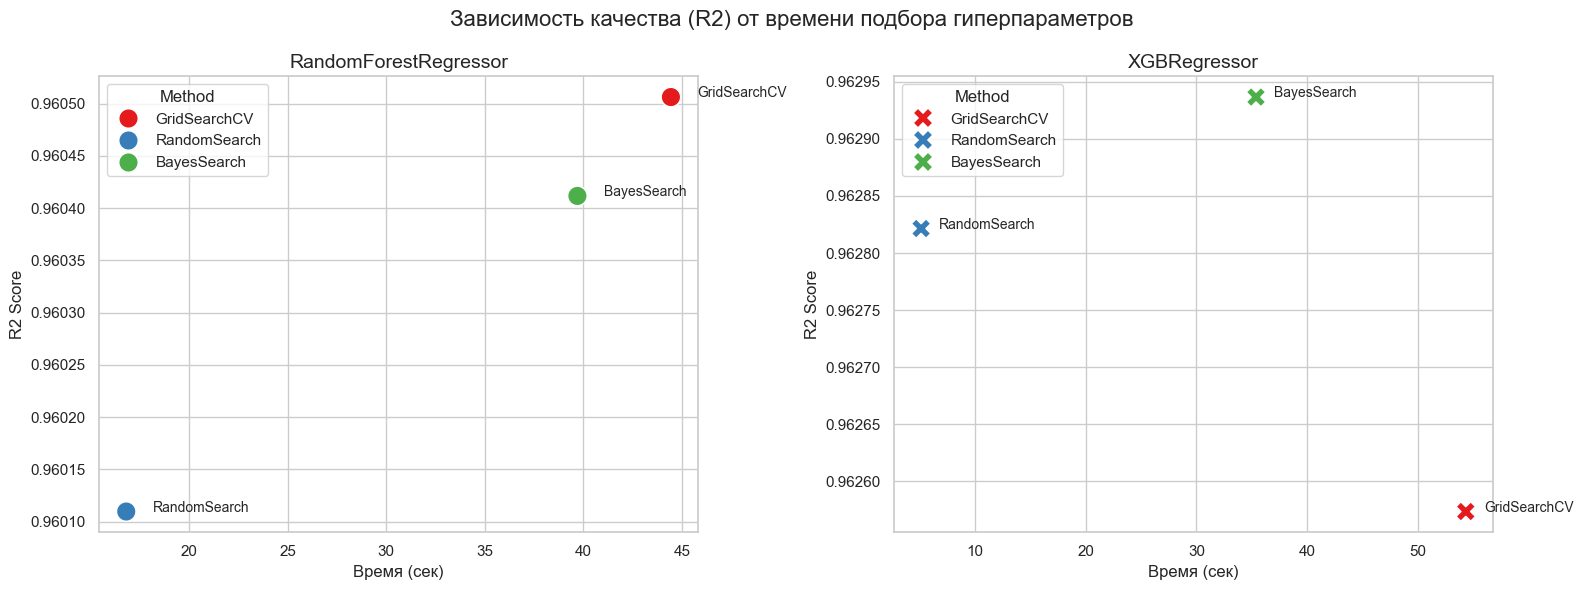

In [6]:
# Создание DataFrame с результатами
results_df = pd.DataFrame(results)
display(results_df)

# Настройки для графиков
sns.set_theme(style="whitegrid")

# Построение графиков: R2 vs Time
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Зависимость качества (R2) от времени подбора гиперпараметров', fontsize=16)

# График для Random Forest
rf_data = results_df[results_df['Model'] == 'RandomForest']
sns.scatterplot(data=rf_data, x='Time (s)', y='R2', hue='Method', s=200, ax=axes[0], palette='Set1', marker='o')
axes[0].set_title('RandomForestRegressor', fontsize=14)
axes[0].set_xlabel('Время (сек)')
axes[0].set_ylabel('R2 Score')

# График для XGBoost
xgb_data = results_df[results_df['Model'] == 'XGBoost']
sns.scatterplot(data=xgb_data, x='Time (s)', y='R2', hue='Method', s=200, ax=axes[1], palette='Set1', marker='X')
axes[1].set_title('XGBRegressor', fontsize=14)
axes[1].set_xlabel('Время (сек)')
axes[1].set_ylabel('R2 Score')

# Добавление аннотаций названий методов рядом с точками
for ax, data in zip(axes, [rf_data, xgb_data]):
    for i in range(data.shape[0]):
        ax.text(data['Time (s)'].iloc[i] + (data['Time (s)'].max() * 0.03), 
                data['R2'].iloc[i], 
                data['Method'].iloc[i], 
                fontsize=10)

plt.tight_layout()
plt.show()